## Prescriptive Analysis

In [19]:
import pandas as pd

In [20]:
df = pd.read_excel("../Source data/Clean_ecom_data.xlsx")
print(df)
df.head(1001)

    Customer ID  Gender   Region Product Name     Category  Age  Unit Price  \
0      CUST0268    Male    North      Monitor  Electronics   49       300.0   
1      CUST0046    Male     West   Headphones  Accessories   22       100.0   
2      CUST0169  Female    South      Monitor  Electronics   54       300.0   
3      CUST0002    Male    North   Headphones  Accessories   23       100.0   
4      CUST0173  Female    South       Laptop  Electronics   49      1500.0   
..          ...     ...      ...          ...          ...  ...         ...   
995    CUST0201  Female    South   Headphones  Accessories   49       100.0   
996    CUST0133    Male     East       Laptop  Electronics   47      1500.0   
997    CUST0055  Female    North        Mouse  Accessories   49        30.0   
998    CUST0023  Female    South       Laptop  Electronics   29      1500.0   
999    CUST0040    Male  Unknown   Smartwatch    Wearables   29       200.0   

     Quantity  Total Price  Shipping Fee Order Date

,Customer ID,Gender,Region,Product Name,Category,Age,Unit Price,Quantity,Total Price,Shipping Fee,Order Date,Shipping Status
0,CUST0268,Male,North,Monitor,Electronics,49,300.0,5,1500,13.31,2023-12-08,Returned
1,CUST0046,Male,West,Headphones,Accessories,22,100.0,2,200,6.93,2023-04-09,In Transit
2,CUST0169,Female,South,Monitor,Electronics,54,300.0,1,300,11.31,2023-08-28,Returned
3,CUST0002,Male,North,Headphones,Accessories,23,100.0,5,500,12.22,2023-01-18,Delivered
4,CUST0173,Female,South,Laptop,Electronics,49,1500.0,3,4500,5.40,2023-01-19,Delivered
...,...,...,...,...,...,...,...,...,...,...,...,...
995,CUST0201,Female,South,Headphones,Accessories,49,100.0,1,100,17.21,2023-01-05,In Transit
996,CUST0133,Male,East,Laptop,Electronics,47,1500.0,1,1500,19.19,2023-04-01,Delivered
997,CUST0055,Female,North,Mouse,Accessories,49,30.0,5,150,19.35,2023-10-20,Delivered
998,CUST0023,Female,South,Laptop,Electronics,29,1500.0,5,7500,10.36,2023-01-07,Returned


### Aggregate Demand by Category
Total demand (quantity sold) per category

In [21]:
demand = df.groupby('Category')['Quantity'].sum()
print("Demand by Category:")
print(demand)


Demand by Category:
Category
Accessories    1228
Electronics    1409
Wearables       371
Name: Quantity, dtype: int64


### Define Costs
- Holding cost → cost of keeping inventory (e.g., $2 per unit).
- Stockout cost → penalty for not meeting demand (e.g., $5 per unit).


In [22]:
holding_cost = 2
stockout_cost = 5

### Prescriptive Rule (Optimal Reorder Quantity)

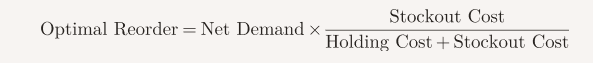

In [23]:
optimal_reorder = demand * (stockout_cost / (holding_cost + stockout_cost))
print("Optimal Reorder Quantities:")
print(optimal_reorder)

Optimal Reorder Quantities:
Category
Accessories     877.142857
Electronics    1006.428571
Wearables       265.000000
Name: Quantity, dtype: float64


# Net demand = demand - returns

In [24]:
returns = df[df['Shipping Status']=="Returned"].groupby('Category')['Quantity'].sum()
net_demand = demand - returns.fillna(0)

optimal_reorder_net = net_demand * (stockout_cost / (holding_cost + stockout_cost))
print("Optimal Reorder Quantities (Adjusted for Returns):")
print(optimal_reorder_net)

Optimal Reorder Quantities (Adjusted for Returns):
Category
Accessories    592.857143
Electronics    704.285714
Wearables      183.571429
Name: Quantity, dtype: float64


#  Vizualization


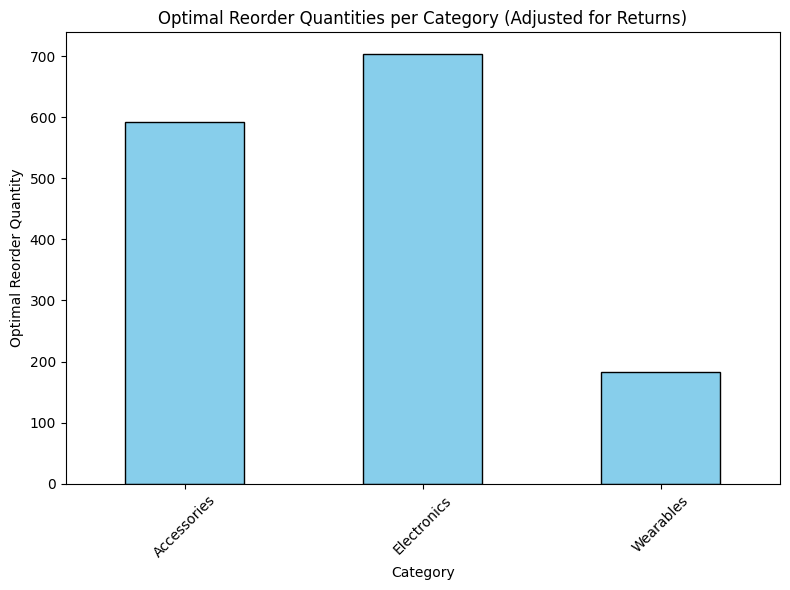

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
optimal_reorder_net.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title("Optimal Reorder Quantities per Category (Adjusted for Returns)")
plt.xlabel("Category")
plt.ylabel("Optimal Reorder Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
